In [1]:
#### import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

########################################
# DEVICE
########################################

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Device:", device)

########################################
# DATASET CLASS
########################################

class OCTDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.images = []
        self.labels = []
        self.transform = transform

        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls:i for i,cls in enumerate(classes)}

        for cls in classes:

            folder = os.path.join(root_dir, cls)

            for img in os.listdir(folder):

                self.images.append(os.path.join(folder,img))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = Image.open(self.images[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]

        return img, label


########################################
# DATA AUGMENTATION
########################################

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

########################################
# DATA PATHS
########################################

train_path = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /train"
val_path   = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /val"
test_path  = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test"

train_dataset = OCTDataset(train_path, train_transform)
val_dataset   = OCTDataset(val_path, test_transform)
test_dataset  = OCTDataset(test_path, test_transform)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=0)
val_loader   = DataLoader(val_dataset,batch_size=32,shuffle=False,num_workers=0)
test_loader  = DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=0)

num_classes = 4

########################################
# CNN PATCH EMBEDDING
########################################

class CNNPatchEmbed(nn.Module):

    def __init__(self, in_channels=3, embed_dim=256):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_channels,64,7,stride=2,padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,embed_dim,3,stride=2,padding=1)
        )

    def forward(self,x):

        x = self.net(x)

        B,C,H,W = x.shape

        x = x.flatten(2).transpose(1,2)

        return x


########################################
# CNN MULTIHEAD ATTENTION
########################################

class CNNMultiHeadAttention(nn.Module):

    def __init__(self, embed_dim=256, heads=8):

        super().__init__()

        self.heads = heads
        self.head_dim = embed_dim // heads

        self.qkv = nn.Linear(embed_dim, embed_dim*3)

        self.conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1)

        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self,x):

        B,N,C = x.shape

        qkv = self.qkv(x).reshape(B,N,3,self.heads,self.head_dim)

        qkv = qkv.permute(2,0,3,1,4)

        q,k,v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2,-1)) / (self.head_dim**0.5)

        attn = attn.softmax(dim=-1)

        out = attn @ v

        out = out.transpose(1,2).reshape(B,N,C)

        conv_out = self.conv(out.transpose(1,2)).transpose(1,2)

        out = out + conv_out

        return self.proj(out)


########################################
# TRANSFORMER ENCODER BLOCK
########################################

class EncoderBlock(nn.Module):

    def __init__(self, embed_dim=256, heads=8):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = CNNMultiHeadAttention(embed_dim,heads)

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim,embed_dim*4),
            nn.GELU(),
            nn.Linear(embed_dim*4,embed_dim)
        )

    def forward(self,x):

        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x


########################################
# HYBRID VISION TRANSFORMER
########################################

class HybridViT(nn.Module):

    def __init__(self, embed_dim=256, depth=8, heads=8, num_classes=4):

        super().__init__()

        self.patch = CNNPatchEmbed(3, embed_dim)

        self.encoder = nn.ModuleList([
            EncoderBlock(embed_dim,heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim,num_classes)

        self.pos_embed = None

    def forward(self,x):

        x = self.patch(x)

        B,N,C = x.shape

        if self.pos_embed is None or self.pos_embed.shape[1] != N:
            self.pos_embed = nn.Parameter(torch.randn(1,N,C).to(x.device))

        x = x + self.pos_embed

        for block in self.encoder:
            x = block(x)

        x = self.norm(x)

        x = x.mean(dim=1)

        return self.head(x)


########################################
# MODEL
########################################

model = HybridViT().to(device)

########################################
# LOSS + OPTIMIZER
########################################

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)

########################################
# TRAINING
########################################

epochs = 5

train_loss_hist = []
val_loss_hist = []

train_acc_hist = []
val_acc_hist = []

for epoch in range(epochs):

    model.train()

    train_loss = 0

    preds = []
    labels = []

    for imgs,lab in tqdm(train_loader):

        imgs = imgs.to(device)
        lab = lab.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs,lab)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds.extend(torch.argmax(outputs,1).cpu().numpy())
        labels.extend(lab.cpu().numpy())

    train_acc = accuracy_score(labels,preds)

    ##################################
    # VALIDATION
    ##################################

    model.eval()

    val_loss = 0

    preds = []
    labels = []

    with torch.no_grad():

        for imgs,lab in val_loader:

            imgs = imgs.to(device)
            lab = lab.to(device)

            outputs = model(imgs)

            loss = criterion(outputs,lab)

            val_loss += loss.item()

            preds.extend(torch.argmax(outputs,1).cpu().numpy())
            labels.extend(lab.cpu().numpy())

    val_acc = accuracy_score(labels,preds)

    scheduler.step()

    train_loss_hist.append(train_loss/len(train_loader))
    val_loss_hist.append(val_loss/len(val_loader))

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Train Acc:",train_acc)
    print("Val Acc:",val_acc)

########################################
# TEST EVALUATION
########################################

model.eval()

preds = []
labels = []
probs = []

with torch.no_grad():

    for imgs,lab in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        prob = torch.softmax(outputs,1)

        preds.extend(torch.argmax(outputs,1).cpu().numpy())
        labels.extend(lab.numpy())
        probs.extend(prob.cpu().numpy())

########################################
# METRICS
########################################

accuracy = accuracy_score(labels,preds)
precision = precision_score(labels,preds,average="macro")
recall = recall_score(labels,preds,average="macro")
f1 = f1_score(labels,preds,average="macro")

print("\nFINAL TEST METRICS")
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

########################################
# CONFUSION MATRIX
########################################

cm = confusion_matrix(labels,preds)
print("\nConfusion Matrix\n",cm)

########################################
# ROC AUC
########################################

labels_bin = label_binarize(labels,classes=[0,1,2,3])
probs = np.array(probs)

plt.figure()

for i in range(num_classes):

    fpr,tpr,_ = roc_curve(labels_bin[:,i],probs[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"Class {i} AUC={roc_auc:.2f}")

plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

########################################
# TRAINING HISTORY
########################################

plt.figure()
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

plt.figure()
plt.plot(train_acc_hist,label="Train Accuracy")
plt.plot(val_acc_hist,label="Val Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

Device: cuda:0


100%|██████████| 2609/2609 [45:43<00:00,  1.05s/it]



Epoch 1/5
Train Acc: 0.7737889895069714
Val Acc: 0.9375


 77%|███████▋  | 2007/2609 [27:33<08:15,  1.21it/s]


KeyboardInterrupt: 

Device: cuda:0

TRAIN DATASET
Total Images: 83484
CNV : 37205
DME : 11348
DRUSEN : 8616
NORMAL : 26315

VALIDATION DATASET
Total Images: 32
CNV : 8
DME : 8
DRUSEN : 8
NORMAL : 8

TEST DATASET
Total Images: 968
CNV : 242
DME : 242
DRUSEN : 242
NORMAL : 242


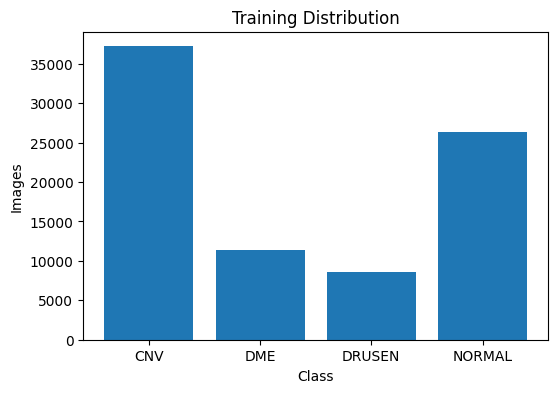

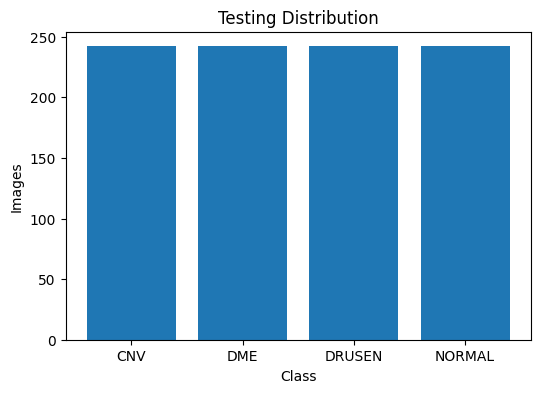

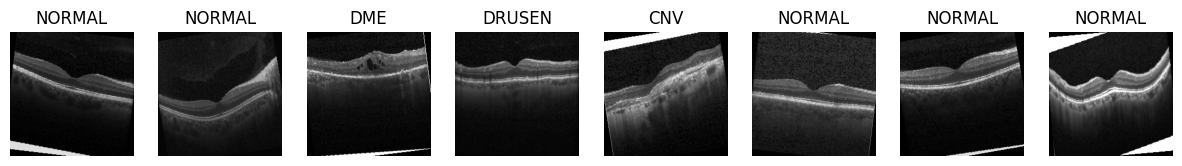


Image Height Mean: 496.0
Image Width Mean: 740.864


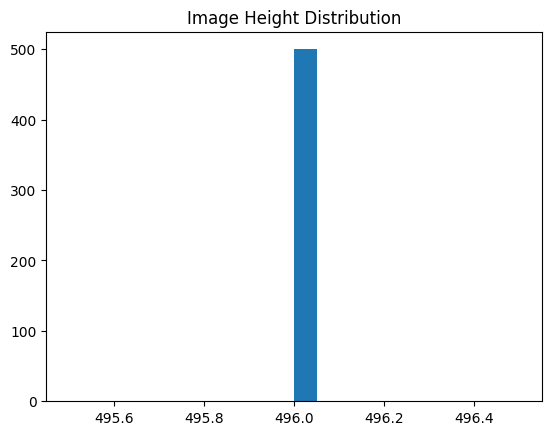

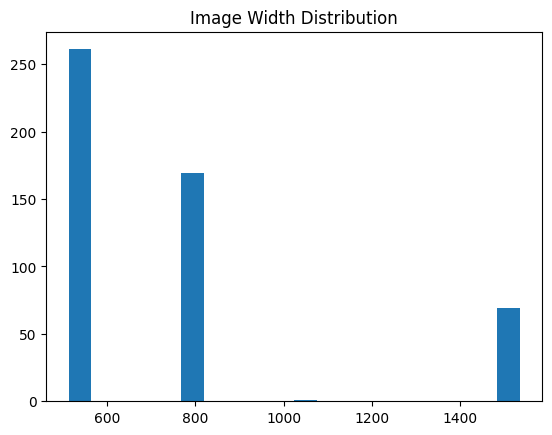

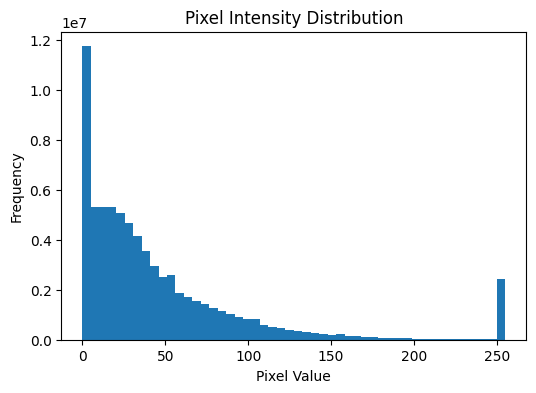

100%|██████████| 2609/2609 [38:43<00:00,  1.12it/s]



Epoch 1/5
Train Acc: 0.7894806190407743
Val Acc: 0.90625


100%|██████████| 2609/2609 [36:19<00:00,  1.20it/s]



Epoch 2/5
Train Acc: 0.8860380432178621
Val Acc: 0.9375


100%|██████████| 2609/2609 [36:02<00:00,  1.21it/s]



Epoch 3/5
Train Acc: 0.9046164534521585
Val Acc: 0.9375


100%|██████████| 2609/2609 [36:02<00:00,  1.21it/s]



Epoch 4/5
Train Acc: 0.9163432514014661
Val Acc: 0.96875


100%|██████████| 2609/2609 [36:43<00:00,  1.18it/s]



Epoch 5/5
Train Acc: 0.9268722150352163
Val Acc: 0.90625

FINAL TEST METRICS
Accuracy : 0.9411157024793388
Precision: 0.9484862904596171
Recall   : 0.9411157024793388
F1 Score : 0.9410788673514405


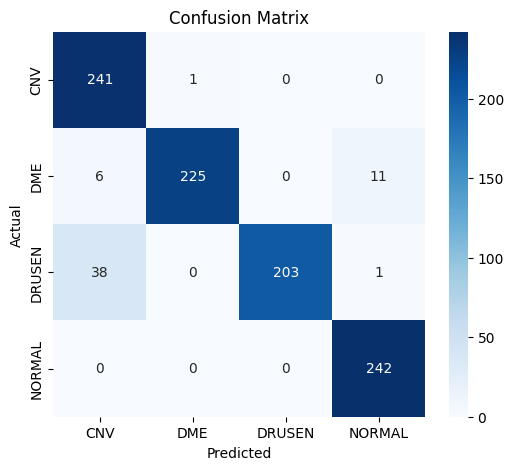

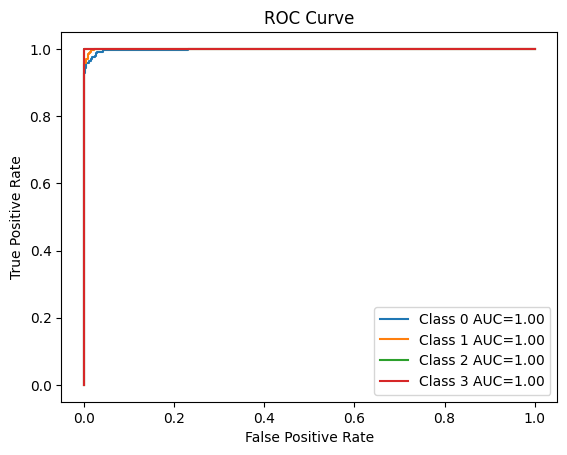

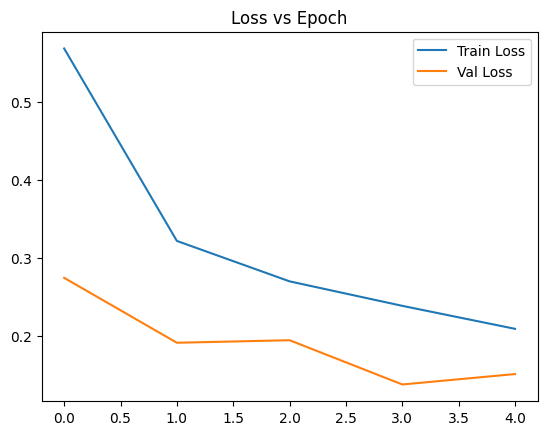

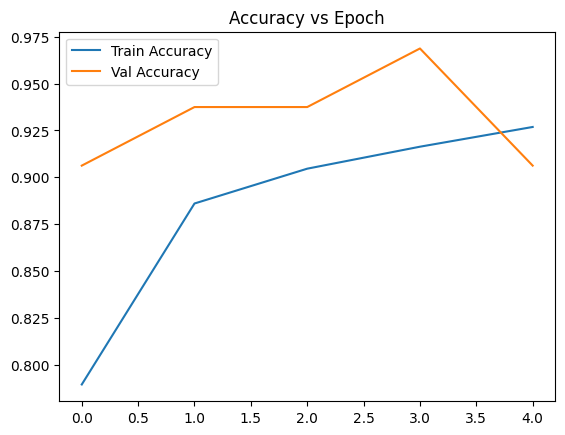

In [2]:
########################################
# IMPORTS
########################################

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

########################################
# DEVICE
########################################

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Device:", device)

########################################
# DATASET CLASS
########################################

class OCTDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.images = []
        self.labels = []
        self.transform = transform

        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls:i for i,cls in enumerate(classes)}

        for cls in classes:

            folder = os.path.join(root_dir, cls)

            for img in os.listdir(folder):

                self.images.append(os.path.join(folder,img))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = Image.open(self.images[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]

        return img, label


########################################
# DATA AUGMENTATION
########################################

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

########################################
# DATA PATHS
########################################

train_path = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /train"
val_path   = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /val"
test_path  = "/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test"

train_dataset = OCTDataset(train_path, train_transform)
val_dataset   = OCTDataset(val_path, test_transform)
test_dataset  = OCTDataset(test_path, test_transform)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=0)
val_loader   = DataLoader(val_dataset,batch_size=32,shuffle=False,num_workers=0)
test_loader  = DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=0)

num_classes = 4


########################################
# DATASET SIZE CHECK
########################################

def dataset_statistics(dataset, name):

    print(f"\n{name} DATASET")

    total = len(dataset)
    print("Total Images:", total)

    class_count = {}

    for label in dataset.labels:
        class_count[label] = class_count.get(label,0) + 1

    for cls, idx in dataset.class_to_idx.items():
        print(f"{cls} :", class_count.get(idx,0))

dataset_statistics(train_dataset,"TRAIN")
dataset_statistics(val_dataset,"VALIDATION")
dataset_statistics(test_dataset,"TEST")


########################################
# EDA — CLASS DISTRIBUTION
########################################

def plot_class_distribution(dataset,title):

    counts = {}

    for label in dataset.labels:
        counts[label] = counts.get(label,0)+1

    names = list(dataset.class_to_idx.keys())
    values = [counts[i] for i in range(len(names))]

    plt.figure(figsize=(6,4))
    plt.bar(names,values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Images")
    plt.show()

plot_class_distribution(train_dataset,"Training Distribution")
plot_class_distribution(test_dataset,"Testing Distribution")


########################################
# EDA — RANDOM IMAGE VISUALIZATION
########################################

def show_random_images(dataset,n=8):

    fig,axs = plt.subplots(1,n,figsize=(15,3))

    for i in range(n):

        idx = random.randint(0,len(dataset)-1)

        img,label = dataset[idx]

        img = img.permute(1,2,0)

        class_name = list(dataset.class_to_idx.keys())[label]

        axs[i].imshow(img)
        axs[i].set_title(class_name)
        axs[i].axis("off")

    plt.show()

show_random_images(train_dataset)


########################################
# EDA — IMAGE SIZE ANALYSIS
########################################

def image_dimension_analysis(dataset, samples=500):

    heights = []
    widths = []

    for i in range(min(samples,len(dataset))):

        img = Image.open(dataset.images[i])

        w,h = img.size

        heights.append(h)
        widths.append(w)

    print("\nImage Height Mean:",np.mean(heights))
    print("Image Width Mean:",np.mean(widths))

    plt.figure()
    plt.hist(heights,bins=20)
    plt.title("Image Height Distribution")
    plt.show()

    plt.figure()
    plt.hist(widths,bins=20)
    plt.title("Image Width Distribution")
    plt.show()

image_dimension_analysis(train_dataset)


########################################
# EDA — PIXEL INTENSITY DISTRIBUTION
########################################

def pixel_distribution(dataset,samples=200):

    pixels = []

    for i in range(samples):

        img = Image.open(dataset.images[i]).convert("L")

        arr = np.array(img).flatten()

        pixels.extend(arr)

    plt.figure(figsize=(6,4))
    plt.hist(pixels,bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

pixel_distribution(train_dataset)


########################################
# CNN PATCH EMBEDDING
########################################

class CNNPatchEmbed(nn.Module):

    def __init__(self, in_channels=3, embed_dim=256):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_channels,64,7,stride=2,padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,embed_dim,3,stride=2,padding=1)
        )

    def forward(self,x):

        x = self.net(x)

        B,C,H,W = x.shape

        x = x.flatten(2).transpose(1,2)

        return x


########################################
# CNN MULTIHEAD ATTENTION
########################################

class CNNMultiHeadAttention(nn.Module):

    def __init__(self, embed_dim=256, heads=8):

        super().__init__()

        self.heads = heads
        self.head_dim = embed_dim // heads

        self.qkv = nn.Linear(embed_dim, embed_dim*3)

        self.conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1)

        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self,x):

        B,N,C = x.shape

        qkv = self.qkv(x).reshape(B,N,3,self.heads,self.head_dim)

        qkv = qkv.permute(2,0,3,1,4)

        q,k,v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2,-1)) / (self.head_dim**0.5)

        attn = attn.softmax(dim=-1)

        out = attn @ v

        out = out.transpose(1,2).reshape(B,N,C)

        conv_out = self.conv(out.transpose(1,2)).transpose(1,2)

        out = out + conv_out

        return self.proj(out)


########################################
# TRANSFORMER ENCODER
########################################

class EncoderBlock(nn.Module):

    def __init__(self, embed_dim=256, heads=8):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = CNNMultiHeadAttention(embed_dim,heads)

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim,embed_dim*4),
            nn.GELU(),
            nn.Linear(embed_dim*4,embed_dim)
        )

    def forward(self,x):

        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x


########################################
# HYBRID VISION TRANSFORMER
########################################

class HybridViT(nn.Module):

    def __init__(self, embed_dim=256, depth=8, heads=8, num_classes=4):

        super().__init__()

        self.patch = CNNPatchEmbed(3, embed_dim)

        self.encoder = nn.ModuleList([
            EncoderBlock(embed_dim,heads)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim,num_classes)

        self.pos_embed = None

    def forward(self,x):

        x = self.patch(x)

        B,N,C = x.shape

        if self.pos_embed is None or self.pos_embed.shape[1] != N:
            self.pos_embed = nn.Parameter(torch.randn(1,N,C).to(x.device))

        x = x + self.pos_embed

        for block in self.encoder:
            x = block(x)

        x = self.norm(x)

        x = x.mean(dim=1)

        return self.head(x)


########################################
# MODEL
########################################

model = HybridViT().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)

########################################
# TRAINING
########################################

epochs = 5

train_loss_hist = []
val_loss_hist = []

train_acc_hist = []
val_acc_hist = []

for epoch in range(epochs):

    model.train()

    train_loss = 0

    preds = []
    labels = []

    for imgs,lab in tqdm(train_loader):

        imgs = imgs.to(device)
        lab = lab.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs,lab)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds.extend(torch.argmax(outputs,1).cpu().numpy())
        labels.extend(lab.cpu().numpy())

    train_acc = accuracy_score(labels,preds)

    ##################################
    # VALIDATION
    ##################################

    model.eval()

    val_loss = 0

    preds = []
    labels = []

    with torch.no_grad():

        for imgs,lab in val_loader:

            imgs = imgs.to(device)
            lab = lab.to(device)

            outputs = model(imgs)

            loss = criterion(outputs,lab)

            val_loss += loss.item()

            preds.extend(torch.argmax(outputs,1).cpu().numpy())
            labels.extend(lab.cpu().numpy())

    val_acc = accuracy_score(labels,preds)

    scheduler.step()

    train_loss_hist.append(train_loss/len(train_loader))
    val_loss_hist.append(val_loss/len(val_loader))

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Train Acc:",train_acc)
    print("Val Acc:",val_acc)

########################################
# TEST EVALUATION
########################################

model.eval()

preds = []
labels = []
probs = []

with torch.no_grad():

    for imgs,lab in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        prob = torch.softmax(outputs,1)

        preds.extend(torch.argmax(outputs,1).cpu().numpy())
        labels.extend(lab.numpy())
        probs.extend(prob.cpu().numpy())

########################################
# METRICS
########################################

accuracy = accuracy_score(labels,preds)
precision = precision_score(labels,preds,average="macro")
recall = recall_score(labels,preds,average="macro")
f1 = f1_score(labels,preds,average="macro")

print("\nFINAL TEST METRICS")
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

########################################
# CONFUSION MATRIX HEATMAP
########################################

cm = confusion_matrix(labels,preds)

class_names = list(test_dataset.class_to_idx.keys())

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

########################################
# ROC CURVE
########################################

labels_bin = label_binarize(labels,classes=[0,1,2,3])
probs = np.array(probs)

plt.figure()

for i in range(num_classes):

    fpr,tpr,_ = roc_curve(labels_bin[:,i],probs[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"Class {i} AUC={roc_auc:.2f}")

plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

########################################
# TRAINING HISTORY
########################################

plt.figure()
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

plt.figure()
plt.plot(train_acc_hist,label="Train Accuracy")
plt.plot(val_acc_hist,label="Val Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()